# 302.2. Stellar multi-color photometry

<div style="max-width:300px; float: left; margin-right: 1em">

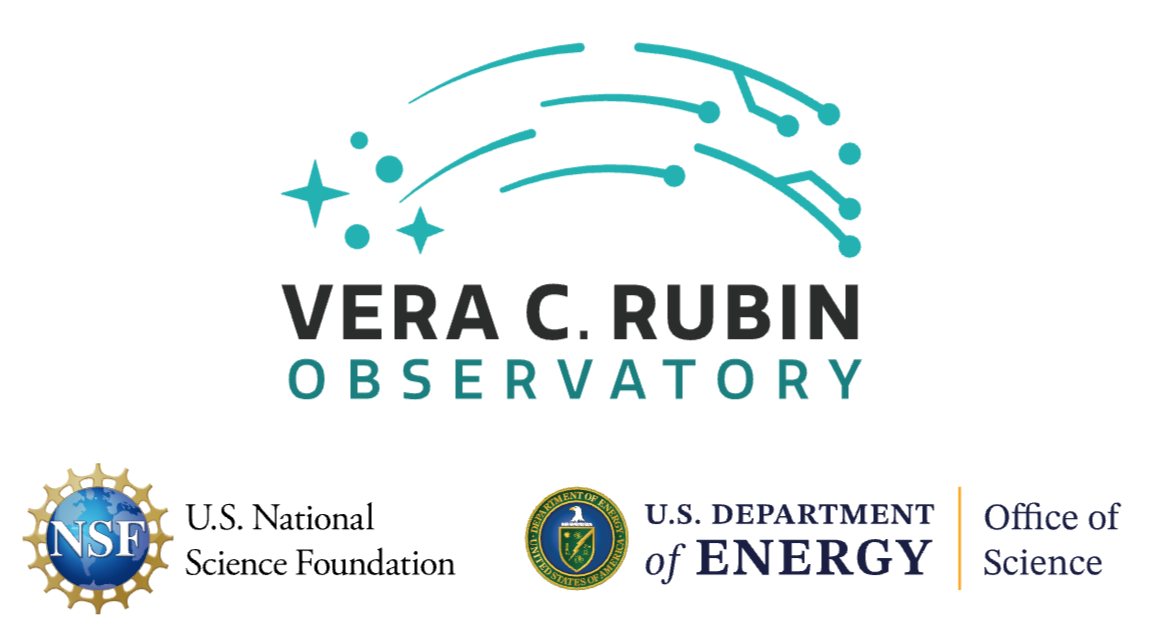

</div>

For the Rubin Science Platform at data.lsst.cloud.\
Data Release: [Data Preview 2](https://dp2.lsst.io)\
Container Size: Small\
LSST Science Pipelines version: r30.0.9\
Last verified to run: 2026-07-19\
Repository: [github.com/lsst/tutorial-notebooks](https://github.com/lsst/tutorial-notebooks)\
DOI: [10.11578/rubin/dc.20250909.20](https://doi.org/10.11578/rubin/dc.20250909.20)

**Learning objective:** Explore stellar color-magnitude and color-color diagrams for NGC 6822.

**LSST data products:** `Object`

**Packages:** `lsst.rsp.RSPDiscovery`

**Credit:**
Originally developed by the Rubin Community Science team. Please consider acknowledging them if this notebook is used for the preparation of journal articles, software releases, or other notebooks. 

**Get Support:**
Everyone is encouraged to ask questions or raise issues in the 
<a href="https://community.lsst.org/c/support">Support Category</a> 
of the Rubin Community Forum.
Rubin staff will respond to all questions posted there.

## 1. Introduction

This tutorial demonstrates the analysis of Rubin DP2 stellar photometry around a nearby galaxy NGC 6822, utilizing color-magnitude diagrams (CMDs) and color-color diagrams (CCDs) to characterize resolved stellar populations and their spatial distributions.

Constructing a Hertzsprung–Russell (H–R) diagram, by plotting stellar luminosity or absolute magnitude against surface temperature or spectral type, reveals distinct evolutionary phases, ranging from the hydrogen-burning main sequence to the evolved giant branches. While these fundamental parameters are traditionally derived via spectroscopy, astronomers leverage multi-band photometry to approximate these physical quantities through observed magnitudes and colors. Analyzing CMDs and CCDs enables the efficient characterization of large, resolved stellar populations and provides a robust framework for age, metallicity, and line-of-sight dust determination.

NGC 6822 is a gas-rich dwarf galaxy, sitting just outside the Milky Way’s virial radius at a distance of ~500 kpc. This galaxy is centered at (RA, Dec) = (296.24, -14.80) degrees.

### 1.1. Import packages

Import `numpy`, a fundamental package for scientific computing with arrays in Python
([numpy.org](https://numpy.org)), and `matplotlib`, a comprehensive library for data visualization
([matplotlib.org](https://matplotlib.org/); [matplotlib gallery](https://matplotlib.org/stable/gallery/index.html)).

From the LSST package ([pipelines.lsst.io](https://pipelines.lsst.io/)), import the RSP Table Access Protocol (TAP) service and the `DustValues` class from the `rubin_sim` package ([rubin_sim](https://rubin-sim.lsst.io/index.html)).

In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
from matplotlib.patches import Polygon, Rectangle, Ellipse, Patch
from matplotlib.path import Path

from lsst.rsp import RSPDiscovery
from rubin_sim.phot_utils import DustValues

### 1.2. Define parameters and functions

Instantiate `RSPDiscovery` with the DP2 release, create an instance of the TAP service, and assert that it exists.

In [ ]:
discovery = RSPDiscovery("dp2")
service = discovery.get_tap_client()

Define a circular region with a 1-degree radius centered on NGC 6822. Coordinates are in degrees.

In [ ]:
ra_cen = 296.24
dec_cen = -14.8
radius = 0.5

Set the environment variable RUBIN_SIM_DATA_DIR to /rubin/rubin_sim_data to make the current `rubin_sim` throughput data available.

In [ ]:
os.environ['RUBIN_SIM_DATA_DIR'] = '/rubin/rubin_sim_data'

List bands that are used in this notebook.

In [ ]:
bands = "gri"

Set font sizes globally for all subsequent `matplotlib` figures in this notebook.

In [ ]:
plt.rcParams["font.size"] = 15
plt.rcParams["figure.titlesize"] = 15
plt.rcParams["legend.fontsize"] = 12
plt.rcParams["axes.titlesize"] = 12

## 2. Construct CMD

Retrieve PSF photometry for stars in the field, apply Galactic dust extinction corrections, and evaluate the impact on ($g-i$, $i$) CMDs.

### 2.1. Query for point-like objects

Query the `Object` table in the Fornax dSph field for coordinates, PSF photometry in $gri$, and $E(B-V)$ values. Restrict to point sources (`refExtendedness` = 0) to only retrieve stars.

In [ ]:
query = """
        SELECT coord_ra, coord_dec, g_psfMag, r_psfMag, i_psfMag, ebv
        FROM dp2.Object
        WHERE CONTAINS(POINT('ICRS', coord_ra, coord_dec),
              CIRCLE('ICRS', {}, {}, {})) = 1
        AND refExtendedness = 0
        AND g_psfFlux/g_psfFluxErr > 5
        AND r_psfFlux/r_psfFluxErr > 5
        AND i_psfFlux/i_psfFluxErr > 5
        """.format(ra_cen, dec_cen, radius)

In [ ]:
job = service.submit_job(query)
job.run()
job.wait(phases=['COMPLETED', 'ERROR'])
print('Job phase is', job.phase)
if job.phase == 'ERROR':
    job.raise_if_error()

Fetch the results, store them as a table.

In [ ]:
df = job.fetch_result().to_table()

### 2.2. Apply dust correction

The `DustValues().r_x` attribute provides the extinction coefficients for the Rubin filters. These coefficients are derived from the CCM89 extinction law ([Cardelli, Clayton, & Mathis 1989](https://ui.adsabs.harvard.edu/abs/1989ApJ...345..245C/abstract)), assuming a flat spectral energy distribution and a default total-to-selective extinction ratio of 3.1, representative of the diffuse Milky Way interstellar medium. Apply dust correction in each filter and save the dust-corrected magnitudes as new columns in the `df` table.

In [ ]:
R_band = DustValues().r_x
A_band = {band: R_band[band] * df['ebv'] for band in bands}
for band in bands:
    df[f"{band}_psfMag0"] = df[f"{band}_psfMag"] - A_band[band]

Compute the average dust correction in $i$ and $g-i$.

In [ ]:
shift_in_i = np.ma.median(A_band['i'])
shift_in_gi = np.ma.median(A_band['g'] - A_band['i'])

print(f"Average extinction in i: {shift_in_i: .3f} mag")
print(f"Average reddening in g-i: {shift_in_gi: .3f} mag")

### 2.3. Dust correction and its impact on the CMD

Construct observed and de-reddened ($g−i$, $i$) CMDs, then subtract the former from the latter to visualize the impact of dust correction on the stellar distribution.

In [ ]:
grid_size = 200
extent = [-1, 3, 14, 26]

counts_obs, xedges, yedges = np.histogram2d(
    df['g_psfMag'] - df['i_psfMag'], df['i_psfMag'],
    bins=grid_size, range=[[extent[0], extent[1]], [extent[2], extent[3]]]
)

counts_corr, _, _ = np.histogram2d(
    df['g_psfMag0'] - df['i_psfMag0'], df['i_psfMag0'],
    bins=grid_size, range=[[extent[0], extent[1]], [extent[2], extent[3]]]
)

diff = counts_corr.T - counts_obs.T 

fig, ax = plt.subplots(figsize=(6, 5))

v_limit = np.percentile(np.abs(diff), 99.5)
im = ax.imshow(diff, extent=extent, aspect='auto', origin='lower',
               cmap='PRGn', vmin=-v_limit, vmax=v_limit, interpolation='nearest')

ax.set_xlim(extent[0], extent[1])
ax.set_ylim(extent[3], extent[2])
ax.set_xlabel(r'$g-i$')
ax.set_ylabel(r'$i$')
ax.arrow(1.5, 15.8, -shift_in_gi, -shift_in_i, color='black', 
         width=0.01, head_width=0.05, length_includes_head=True)
ax.text(2, 16.5, 'Dust\nCorrection', color='black', ha='center')

cbar = fig.colorbar(im, ax=ax, label='De-reddened CMD - Observed CMD')
plt.show()

> **Figure 1:** Residual 2-dimensional histogram illustrating the shift in the ($g-i$, $i$) CMD of NGC 6822 after applying Galactic dust corrections. The color scale represents the change in stellar counts per bin ($\Delta$N = N$_{corrected}$ - N$_{observed}$), where purple (negative) regions indicate the original observed positions of stars and green (positive) regions represent their intrinsic, de-reddened positions. The black vector denotes the direction and magnitude of the correction, demonstrating the systematic recovery of the stellar locus toward higher effective temperatures and luminosities.

## 3. Classification of stellar evolutionary phases 

CMDs provide a powerful diagnostic for disentangling the complex star formation history of a stellar system. By defining geometric selection criteria in an CMD, it is possible to isolate distinct stellar populations in the stellar system. In this section, we apply these selections to the de-reddened ($g−i$, $i$) CMD of NGC 6822 to classify individual stars by evolutionary phase, facilitating a comparative study of their spatial and photometric distributions.

### 3.1. Identify key evolutionary phases
Classify key evolutionary phases, including the upper Main Sequence (MS; young hydrogen-burning stars) and Red Giant Branch (RGB; evolved stars with helium cores and hydrogen-burning shells), within the CMD.

In [ ]:
phase_colors = {
    'MS': 'tab:blue',
    'RGB': 'tab:red',
}

regions = [
    {'type': 'poly', 'label': 'MS',
     'xy': [(-1.0, 16.0), (-0.5, 16), (0.0, 24.1), (-1.0, 24.1)],
     'edgecolor': phase_colors['MS']},
    {'type': 'poly', 'label': 'RGB',
     'xy': [(0.1, 24.0), (0.8, 22.0), (1.4, 20.0), (1.8, 20.0), (1.3, 22.5), (1.3, 23.0)],
     'edgecolor': phase_colors['RGB']}
]

In [ ]:
fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(counts_corr.T, extent=extent, norm=LogNorm(), aspect='auto',
               origin='lower', cmap=plt.cm.Greys, interpolation='nearest')
ax.set_xlim(extent[0], extent[1])
ax.set_ylim(extent[3], extent[2])
ax.set_xlabel(r'$g_0 - i_0$')
ax.set_ylabel(r'$i_0$')

legend_elements = []
for reg in regions:
    if reg['type'] == 'rect':
        patch = Rectangle(reg['xy'], reg['width'], reg['height'], 
                          fill=False, lw=2, edgecolor=reg['edgecolor'], label=reg['label'])
    elif reg['type'] == 'poly':
        patch = Polygon(reg['xy'], fill=False, lw=2, edgecolor=reg['edgecolor'], label=reg['label'])
    
    ax.add_patch(patch)
    legend_elements.append(patch)

ax.legend(handles=legend_elements, loc='upper left')

plt.show()

> **Figure 2:** Dust-corrected ($g−i$, $i$) CMD of the NGC 6822 field. Overlaid geometric regions (polygons) define the selection criteria used to isolate distinct evolutionary phases; MS and RGB. 

### 3.2. Tag stars with evolutionary phase

Define functions to filter stars using the selection masks established in the previous section.

In [ ]:
def get_poly_mask(color, mag, vertices):
    """
    Generate a boolean mask for points falling within a specified 2D polygon.

    Parameters
    ----------
    color : array-like
        1D array of stellar color indices (e.g., g - i).
    mag : array-like
        1D array of stellar magnitudes (e.g., i).
    vertices : list of tuples
        A list of (x, y) coordinates defining the polygon vertices in the 
        (color, mag) plane.

    Returns
    -------
    mask : numpy.ndarray
        A boolean array where True indicates the point is inside the polygon.
    """
    path = Path(vertices)
    points = np.column_stack((color, mag))
    
    return path.contains_points(points)

Apply the selection masks, assign labels to each population, and add a categorical column (`phase_label`) to the `df` table. 

In [ ]:
df['phase_label'] = 'unclassified'

for reg in regions:
    mask = get_poly_mask(df['g_psfMag0'] - df['i_psfMag0'], df['i_psfMag0'], reg['xy'])
    df['phase_label'][mask] = reg['label']

## 4. Multi-Diagnostic Visualization

Examine the distribution of each labeled population in both color-color and spatial planes. Using these combined diagnostics has great potential to identify population-specific trends, such as spatial gradients, and to ensure the purity of the isolated evolutionary phases.

### 4.1. CCD diagnostics 

Visualize how these CMD-selected populations behave in the color-color space ($g-i$, $r-i$).

In [ ]:
fig, ax = plt.subplots(figsize=(6, 5))

gi = df['g_psfMag0'] - df['i_psfMag0']
ri = df['r_psfMag0'] - df['i_psfMag0']

ms_mask = df['phase_label'] == 'MS'
rgb_mask = df['phase_label'] == 'RGB'
cont_mask = df['phase_label'] == 'unclassified'

hist_kwargs = {
    'bins': 200,
    'range': ((-1, 2), (-1, 2)),
    'norm': LogNorm(),
}

h_cont = ax.hist2d(gi[cont_mask], ri[cont_mask], cmap='Greys', **hist_kwargs)
h_ms = ax.hist2d(gi[ms_mask], ri[ms_mask], cmap='Blues', alpha=0.7, **hist_kwargs)
h_rgb = ax.hist2d(gi[rgb_mask], ri[rgb_mask], cmap='Reds', alpha=0.7, **hist_kwargs)

ax.set_xlim(-1, 2)
ax.set_ylim(-1, 2)
ax.set_xlabel('$g_0 - i_0$')
ax.set_ylabel('$r_0 - i_0$')

cont_patch = Patch(color='gray', label=f"Unclassified (N={cont_mask.sum():,})")
ms_patch = Patch(color=phase_colors['MS'], label=f"MS (N={ms_mask.sum():,})")
rgb_patch = Patch(color=phase_colors['RGB'], label=f"RGB (N={rgb_mask.sum():,})")

ax.legend(handles=[cont_patch, ms_patch, rgb_patch], loc='upper left', frameon=True)

plt.tight_layout()
plt.show()

> **Figure 3:** Distribution of each labeled population in the ($g-i$, $r-i$) CCD. Note that while each population occupies a distinct region of the CCD, they collectively define the stellar locus.

### 4.2. Spatial distribution by populations

Explore spatial distribution of distinct populations within the field footprint. Note that the lack of stars in the inner region is an artifact of the LSST Science Pipelines skipping the deblending process in crowded areas.

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
axes = axes.flatten()

labels = np.unique(df['phase_label'])
for i, label in enumerate(labels):
    ax = axes[i]
    group = df['phase_label'] == label

    ax.scatter(df['coord_ra'][group], df['coord_dec'][group], s=1, alpha=0.3)
    ax.set_title(f"Phase: {label}", fontweight='bold')
    ax.invert_xaxis()
    ax.set_xlabel('RA [deg]')
    if i == 0:
        ax.set_ylabel('Dec [deg]')

plt.tight_layout()
plt.show()

> **Figure 4:** Spatial distribution of MS, RGB, and unclassified point-like sources in the NGC 6822 field. North is up, and East is to the left. Young MS stars are elongated along the NW-SE direction with a position angle of ~125 deg, and are closely confined within the high-density HI gas contours (see figure below). In contrast to the young populations, the old RGB stars exhibit a more spheroidal 2D distribution. Lastly, the unclassified point-like sources (likely Milky Way foreground contamination) exhibit a nearly uniform 2D distribution.

<div style="max-width:500px;">

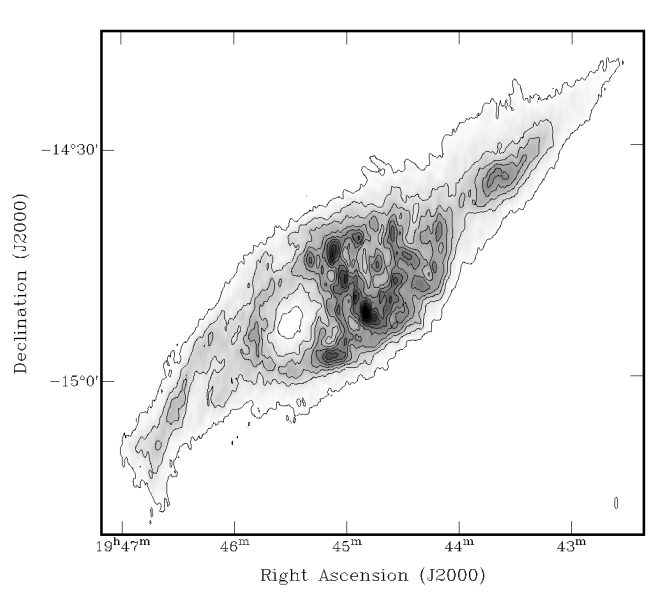

</div>

> **Figure 5:** HI gas density map for NGC 6822, adopted from Figure 1 of [de Blok & Walter (2000)](https://iopscience.iop.org/article/10.1086/312777).